# Prototype Benchmark Visualizations

This notebook documents the 4-sequence thermodynamic stress panel used before scaling to the full ~2,396-row balanced set:

- **FourU (73 nt)** — canonical positive; validates sigmoidal Hill fitting on the SD window
- **cspA-425** — anomaly case with flat/inverted melting asymptotes
- **Guanidine-II (47 nt)** — short negative baseline for leakiness / amplitude
- **cspA-512** — O(N³) RAM stress test for cloud provisioning

All plotting logic lives in `src/thermo_sim/plot_prototype_benchmark.py`; this notebook regenerates figures and displays them inline.

In [1]:
%matplotlib inline

import sys
from pathlib import Path

from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from thermo_sim.plot_prototype_benchmark import (
    OUTPUT_DIR,
    generate_all_figures,
    load_benchmark_report,
    load_fused_features,
)

Matplotlib is building the font cache; this may take a moment.


In [2]:
report = load_benchmark_report()
fused = load_fused_features()
print(f"Sequences: {len(report['sequences'])}, fused rows: {len(fused)}")
print(f"Chosen Vienna dangles: -d{report['biophysics']['chosen_vienna_dangles']}")

Sequences: 4, fused rows: 4
Chosen Vienna dangles: -d2


In [3]:
figure_paths = generate_all_figures()
for path in figure_paths:
    print(path)

/Users/amierzuhri/arcblanc/Thermoswitches-MLBIO/reports/figures/prototype/length_vs_cost_scatter.png
/Users/amierzuhri/arcblanc/Thermoswitches-MLBIO/reports/figures/prototype/categorical_bars.png
/Users/amierzuhri/arcblanc/Thermoswitches-MLBIO/reports/figures/prototype/feature_distribution_violin.png
/Users/amierzuhri/arcblanc/Thermoswitches-MLBIO/reports/figures/prototype/melting_profiles_hill_overlay.png


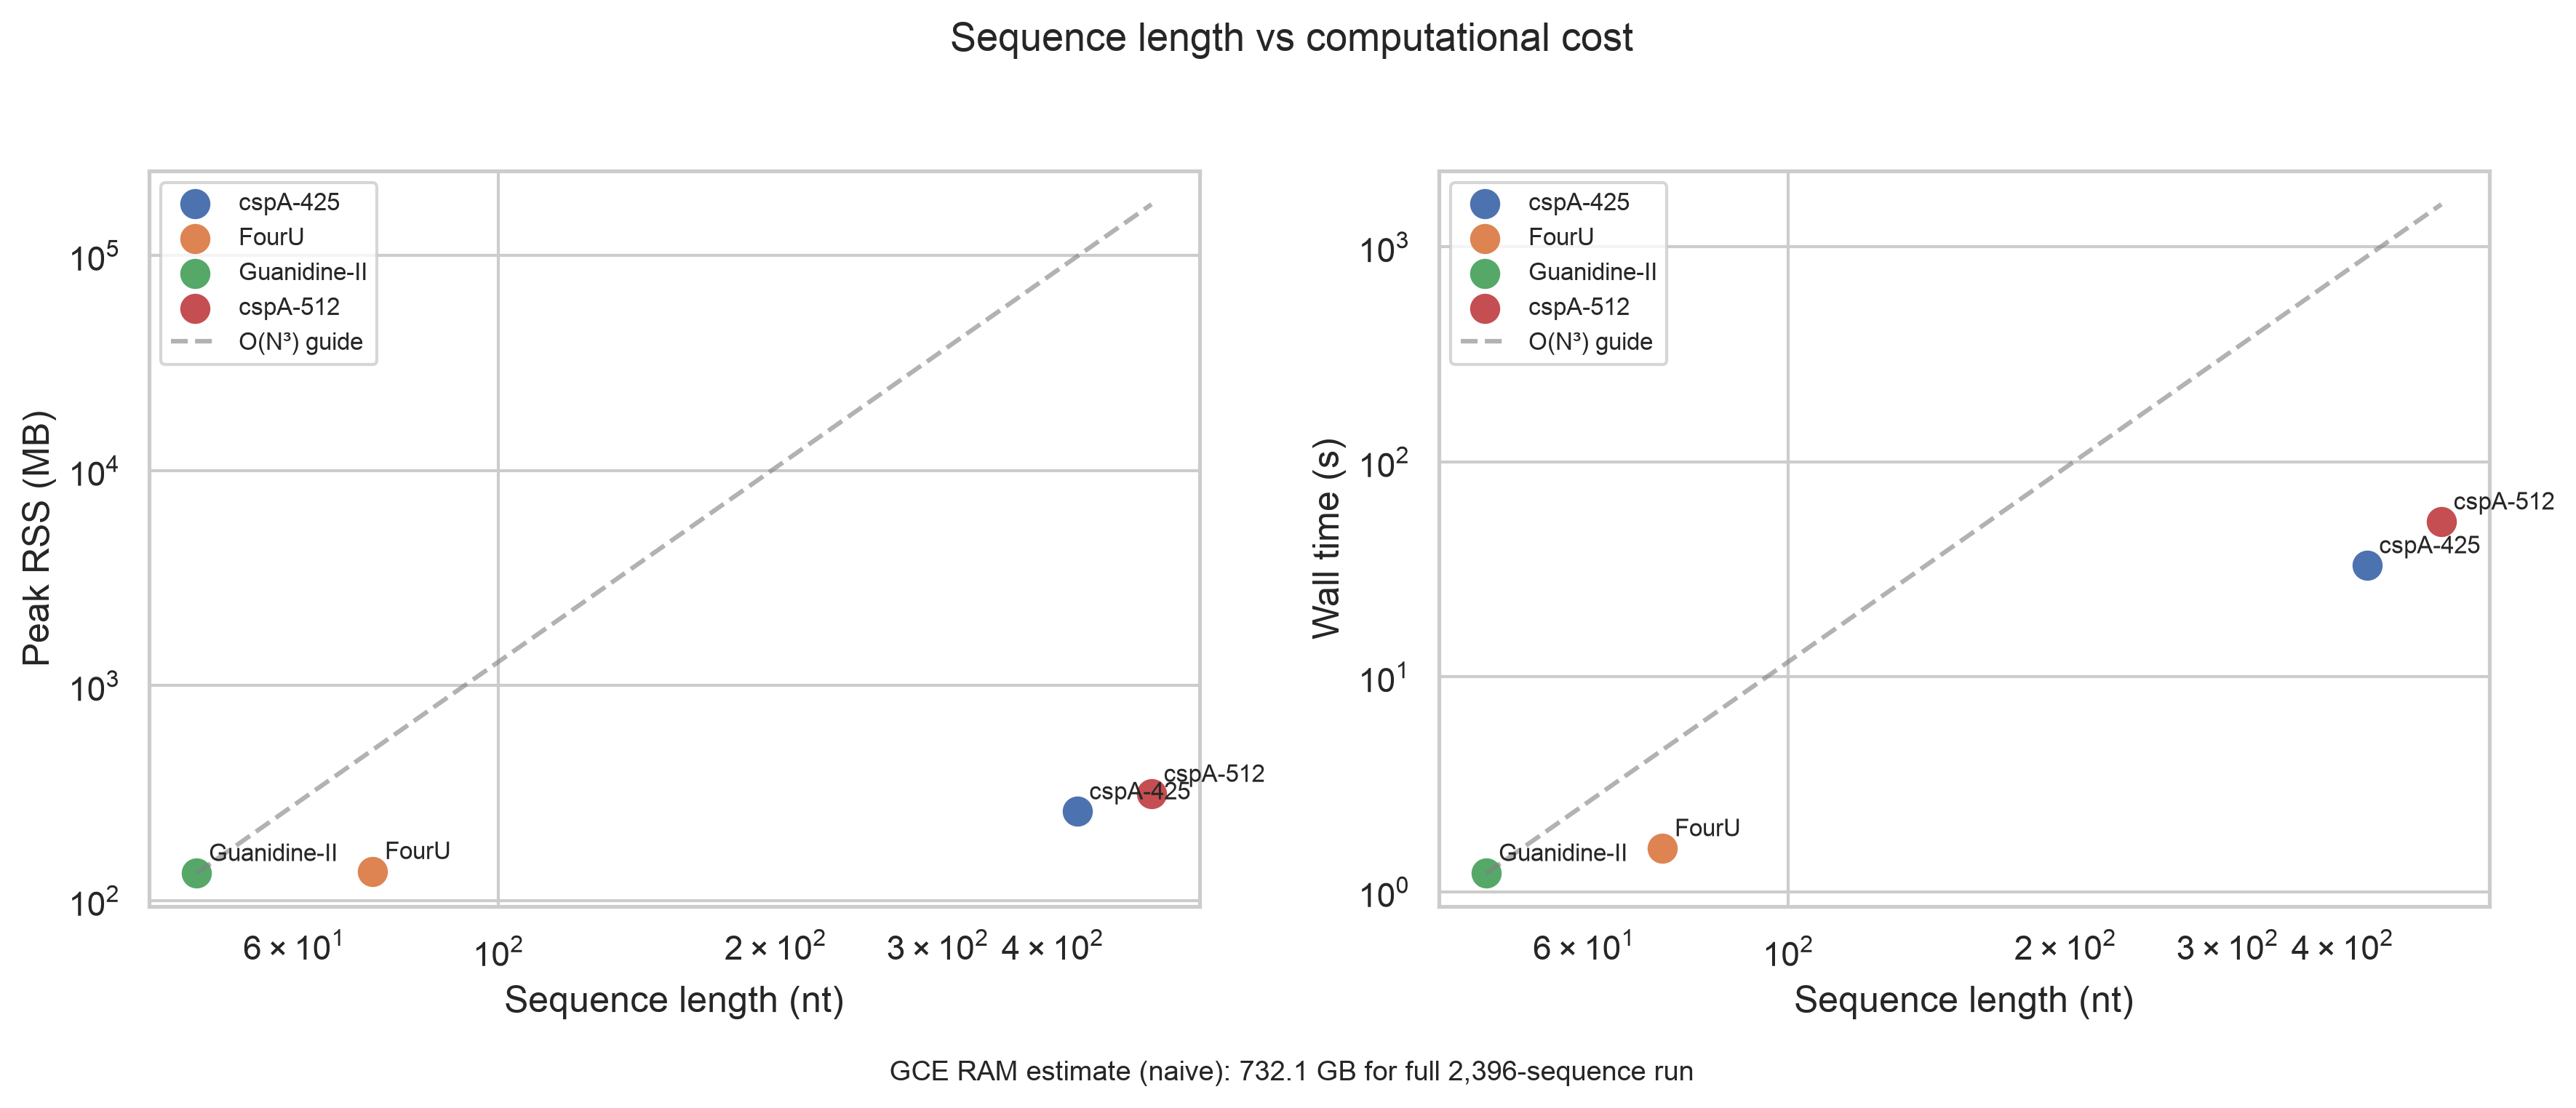

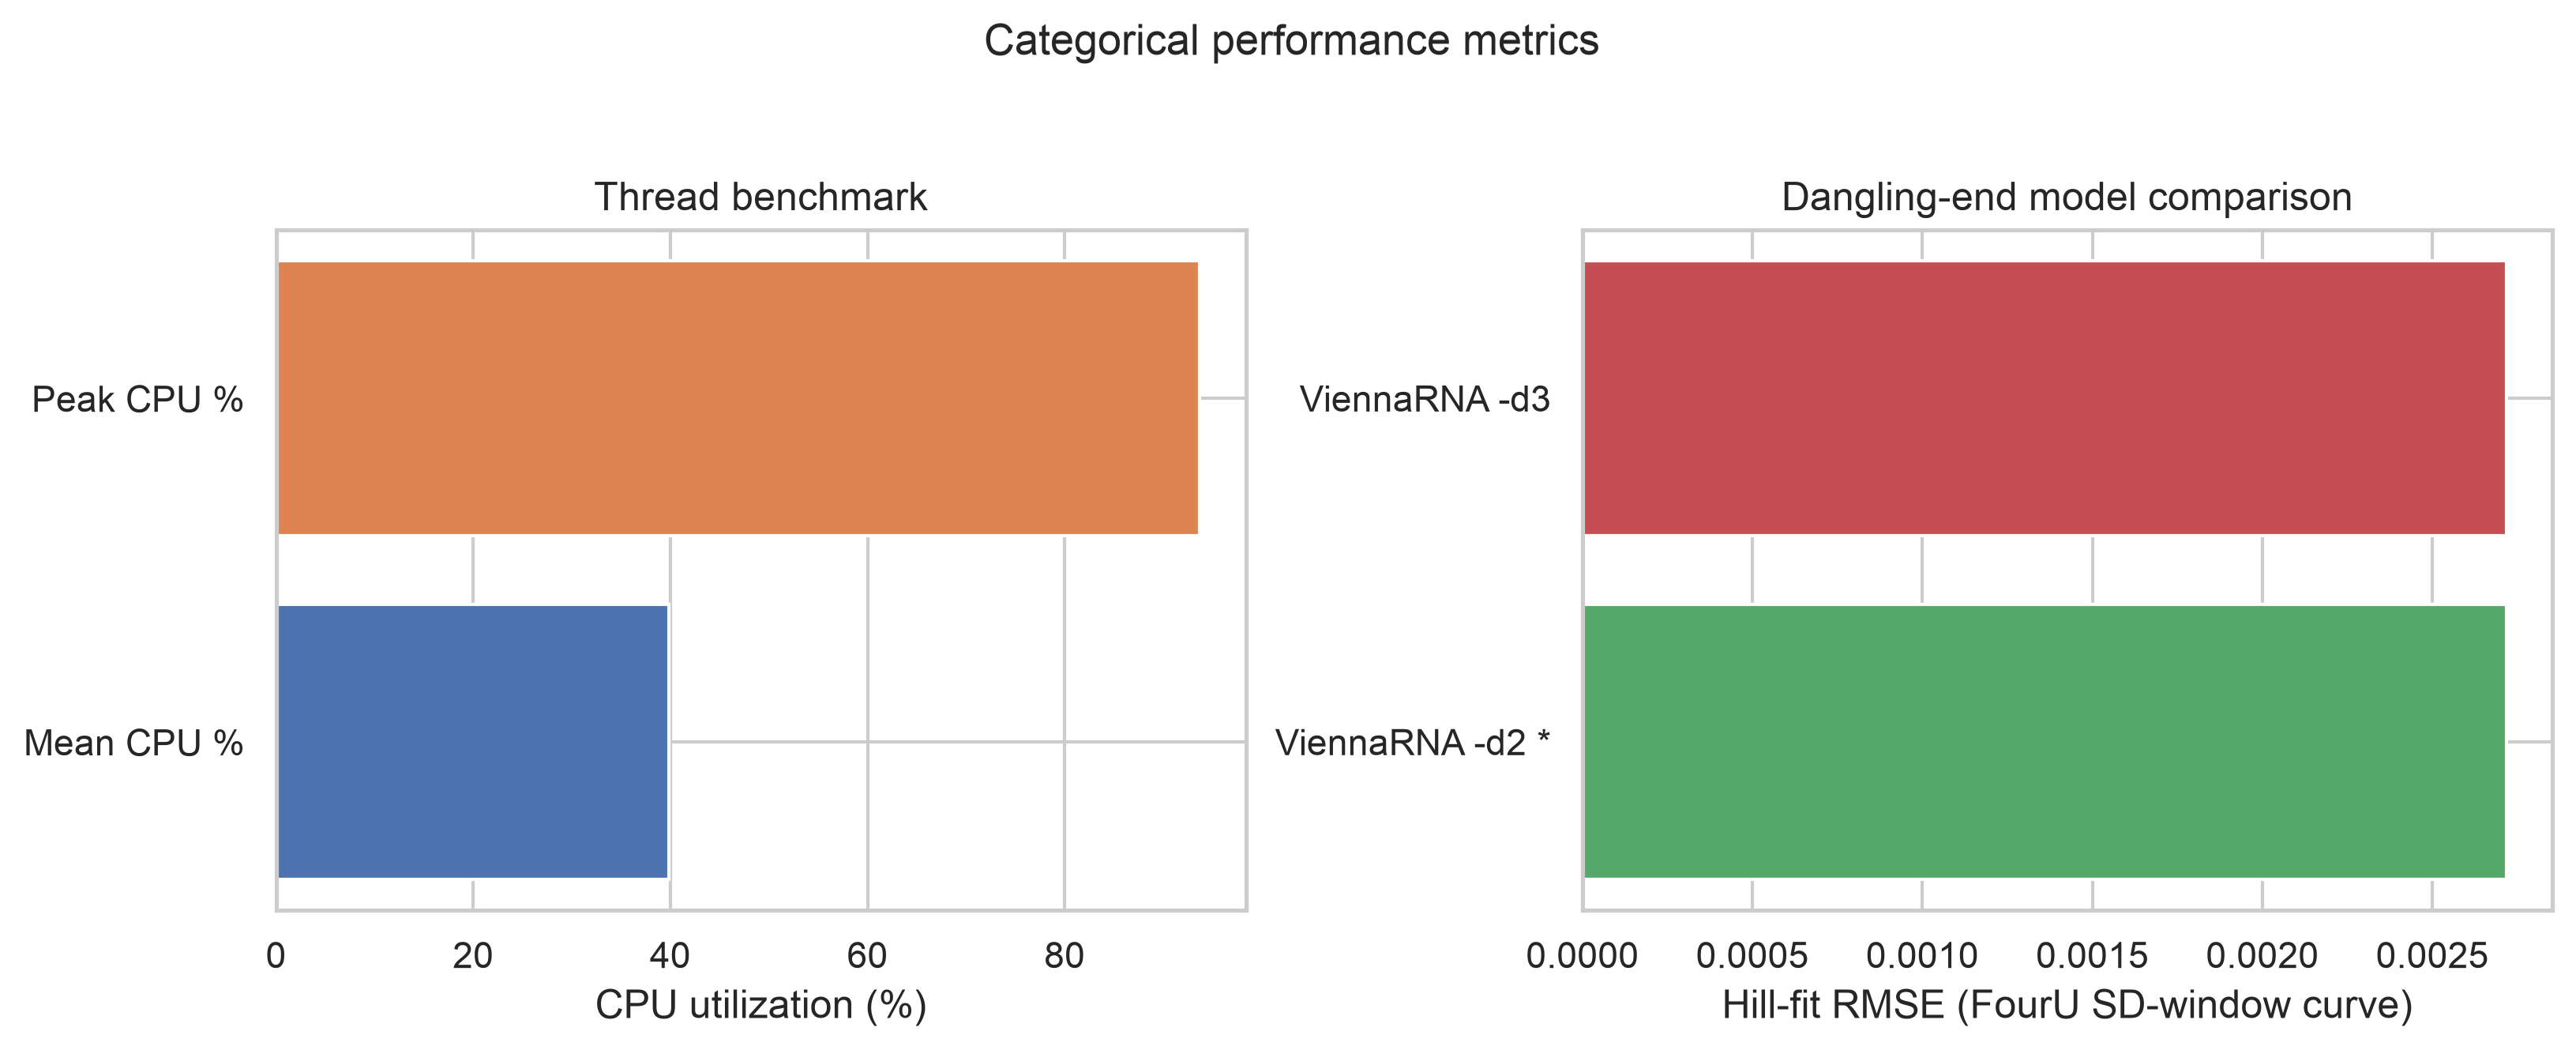

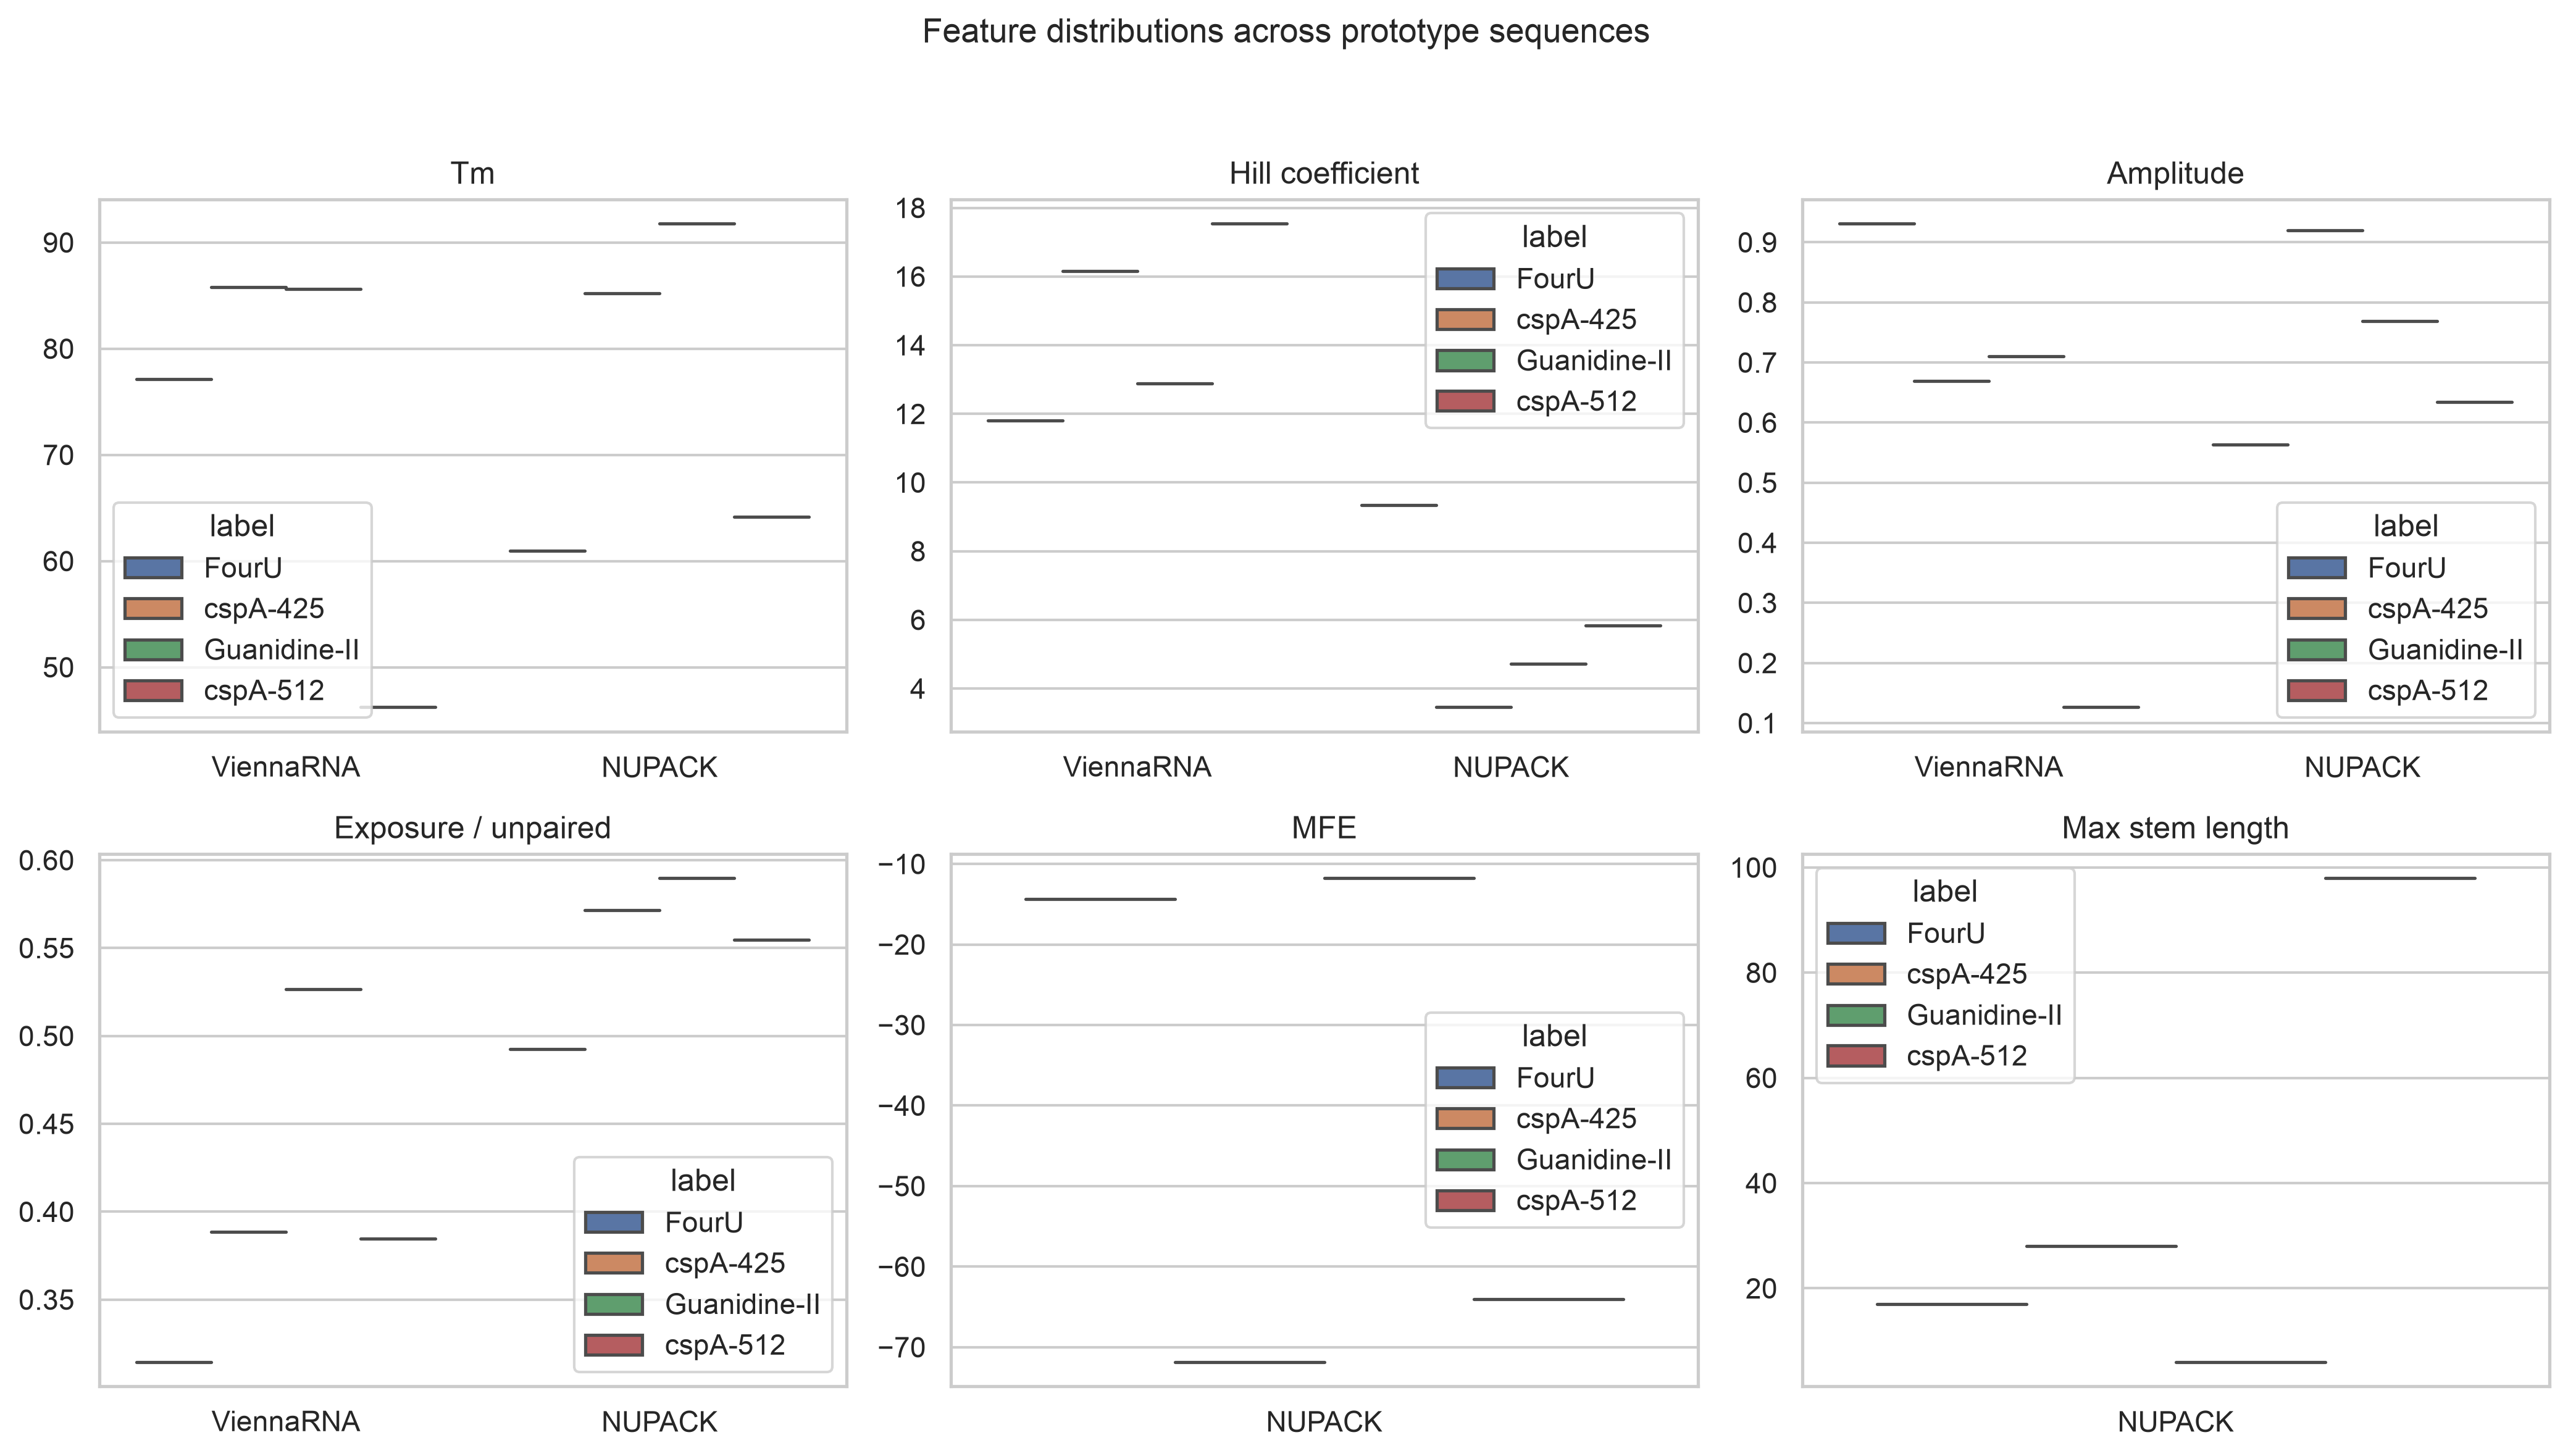

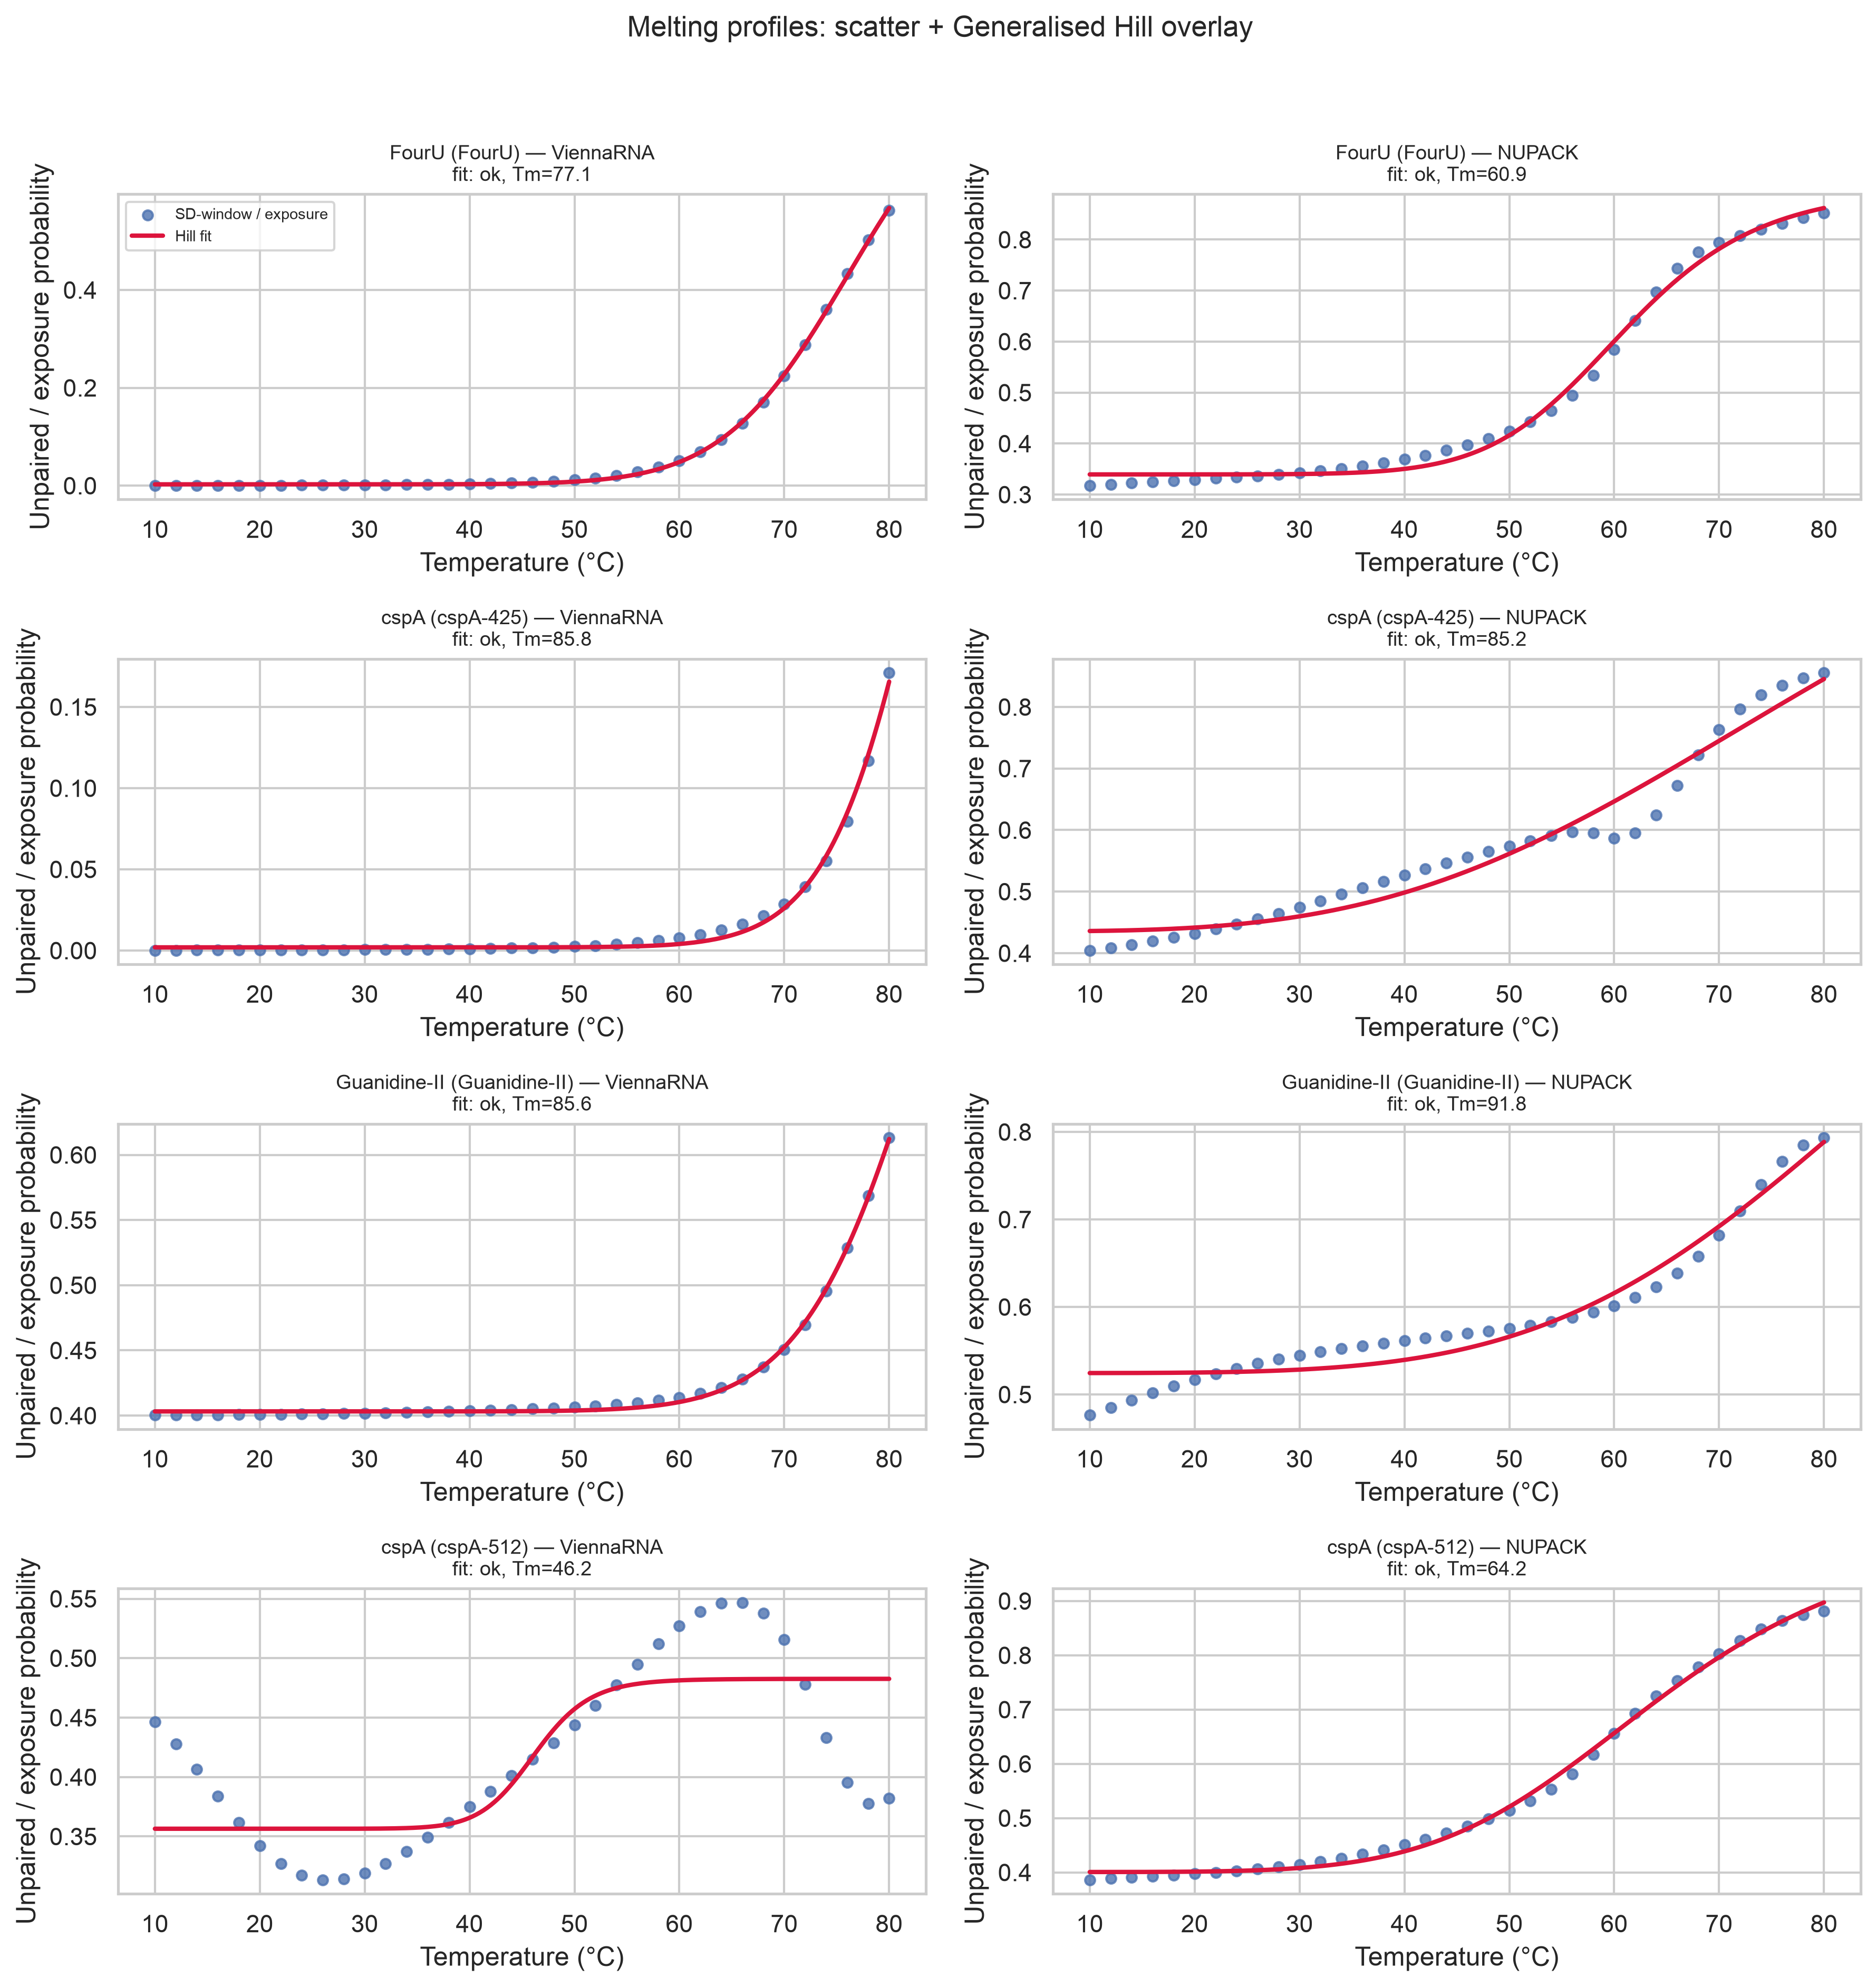

In [4]:
figures = [
    "length_vs_cost_scatter.png",
    "categorical_bars.png",
    "feature_distribution_violin.png",
    "melting_profiles_hill_overlay.png",
]
output_dir = PROJECT_ROOT / OUTPUT_DIR
for name in figures:
    display(Image(filename=str(output_dir / name)))

## Interpretation notes (supervisor-facing)

- **Length vs cost (log-log):** The 512 nt cspA point dominates peak RSS; the dashed O(N³) guide is illustrative (not a fitted scaling law) but supports the naive GCE RAM estimate in the caption.
- **CPU bars:** Mean vs peak CPU under 4 parallel workers shows headroom for thread tuning before full-dataset runs.
- **d2 vs d3:** Horizontal bars compare Hill-fit RMSE on the FourU SD-window curve; the asterisk marks the chosen `-d2` model.
- **Feature violins:** Four points per violin (one per panel sequence). Values are raw engine outputs — z-scoring per feature is optional for side-by-side comparability.
- **Melting overlays:** Scatter points are the exact curves fed to `scipy.optimize.curve_fit`; the red line is a dense Generalised Hill sigmoid from re-fitted parameters. Compare FourU sigmoidal behavior vs cspA flat/inverted profiles across ViennaRNA and NUPACK.